In [26]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [28]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [29]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

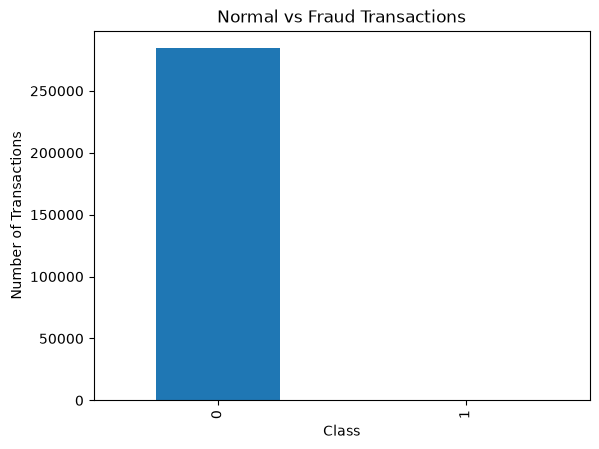

In [30]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

In [31]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [32]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [34]:
from imblearn.over_sampling import SMOTE

In [35]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [37]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

Precision: 0.13414634146341464
Recall: 0.8979591836734694
ROC-AUC: 0.9764816590676788


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [39]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("ROC-AUC:", roc_auc_rf)

Random Forest Results
---------------------
Precision: 0.4195121951219512
Recall: 0.8775510204081632
ROC-AUC: 0.9819844053265652


In [40]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [41]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(y_prob_rf[:20])

[0.00683909 0.014538   0.09502392 0.00455263 0.28307438 0.02460703
 0.007991   0.00879324 0.00975497 0.00233856 0.15299539 0.23494861
 0.00614298 0.0061604  0.00233856 0.00325314 0.03601134 0.00373675
 0.01251192 0.0220679 ]


In [42]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("ROC-AUC:", roc_auc_rf)

Random Forest Results
---------------------
Precision: 0.4195121951219512
Recall: 0.8775510204081632
ROC-AUC: 0.9819844053265652


[[56745   119]
 [   12    86]]


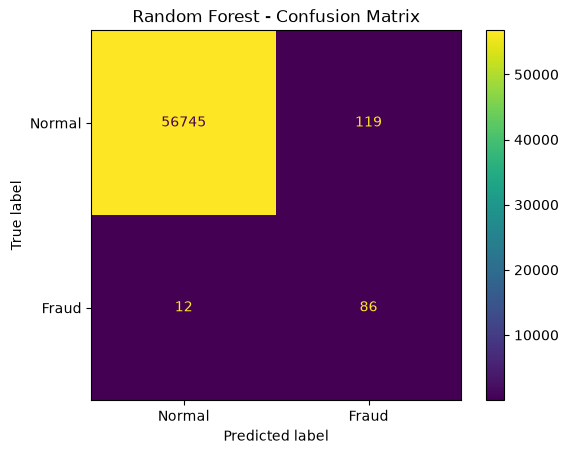

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [10, 20],
    "max_depth": [5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 20}
Best ROC-AUC: 0.9997068994571116


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

models = {
    "RF_10_10": RandomForestClassifier(
        n_estimators=10,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "RF_20_10": RandomForestClassifier(
        n_estimators=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "RF_10_15": RandomForestClassifier(
        n_estimators=10,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    probability = model.predict_proba(X_test)[:, 1]

    score = roc_auc_score(y_test, probability)

    print(name, "ROC-AUC:", score)

RF_10_10 ROC-AUC: 0.9819844053265652
RF_20_10 ROC-AUC: 0.9828301396529349
RF_10_15 ROC-AUC: 0.969134106582982


In [19]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_smote, y_train_smote)

print("Best Random Forest trained!")

Best Random Forest trained!


In [20]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

   Feature  Importance
14     V14    0.343992
17     V17    0.158876
10     V10    0.106096
12     V12    0.090651
3       V3    0.068347
4       V4    0.062689
16     V16    0.032864
2       V2    0.030075
9       V9    0.025051
18     V18    0.008015


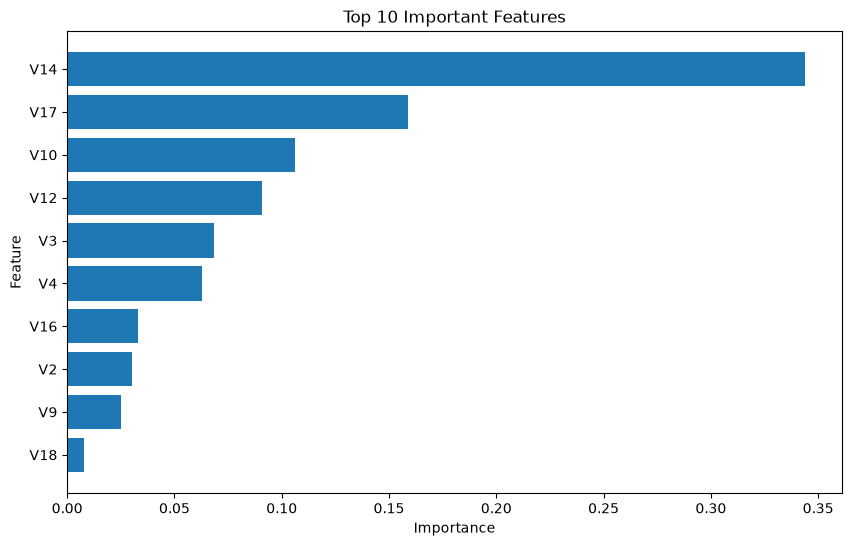

In [21]:
import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()

plt.show()

In [22]:
import joblib

In [23]:
joblib.dump(best_rf, "fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [24]:
import joblib

loaded_model = joblib.load("fraud_detection_model.pkl")

prediction = loaded_model.predict(X_test)

print("Model loaded successfully!")
print("First 20 predictions:", prediction[:20])

Model loaded successfully!
First 20 predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [25]:
new_transaction = X_test.iloc[[0]]

prediction = loaded_model.predict(new_transaction)[0]
probability = loaded_model.predict_proba(new_transaction)[0][1]

print("Prediction:", prediction)
print("Fraud Probability:", probability)

Prediction: 0
Fraud Probability: 0.018459499991773345


In [44]:
import joblib

joblib.dump(
    best_rf,
    r"C:\Users\DELL\OneDrive\Desktop\Fraud_Detection\models\fraud_detection_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [45]:
test_transaction = X_test.iloc[0]

print(test_transaction.to_dict())

{'Time': 160760.0, 'V1': -0.674466064578314, 'V2': 1.40810501967799, 'V3': -1.11062205357093, 'V4': -1.32836577843066, 'V5': 1.38899603254837, 'V6': -1.30843906707795, 'V7': 1.88587890268717, 'V8': -0.614232966299775, 'V9': 0.311652212453101, 'V10': 0.65075700363522, 'V11': -0.857784661547805, 'V12': -0.229961445775592, 'V13': -0.19981700479103, 'V14': 0.266371326329879, 'V15': -0.0465441684754424, 'V16': -0.741398089749789, 'V17': -0.605616644106022, 'V18': -0.39256818789208, 'V19': -0.162648311024695, 'V20': 0.394321820843914, 'V21': 0.0800842396026648, 'V22': 0.810033595602455, 'V23': -0.224327230436412, 'V24': 0.707899237446867, 'V25': -0.13583702273753, 'V26': 0.0451021964988772, 'V27': 0.533837219064273, 'V28': 0.291319252625364, 'Amount': 23.0}
